# Logistic Regression -- End to End with the Adult Income Dataset

Linear regression predicts a *number*. But what if the thing we want to predict is a *category*? Did the email get clicked or not? Will the loan default or not? Does this person earn more than \$50,000 a year or not?

For those questions we need **logistic regression** -- the workhorse algorithm for binary classification. Despite the name, it's not a regression at all: it's a classifier that outputs a probability between 0 and 1.

In this notebook we'll work through the *whole* pipeline end-to-end. Along the way we'll meet the sigmoid function, learn why we standardise our features, and figure out how to read the model's coefficients as odds ratios.

**The dataset.** We'll use the classic *Adult Income* dataset from the US Census. Each row is a person, with 14 features describing their demographics and employment. The target is whether their income exceeds \$50K/year.

**The journey:**
1. Load the data and look at it
2. Explore: how does each feature relate to income?
3. Prepare: clean, encode, scale, split
4. Build: simple model -> full model
5. Evaluate: accuracy, precision, recall, F1, ROC-AUC
6. Diagnose: where is the model wrong?
7. Interpret: which features matter most, and by how much?

## 1. Import Libraries

Three groups of imports:
- **Data + plotting:** pandas, numpy, matplotlib, seaborn.
- **Modelling:** scikit-learn's `LogisticRegression`, the train/test splitter, and the `StandardScaler` (we'll see why we need it shortly).
- **Evaluation:** classification metrics + calibration curve, which we'll explain at the point we use them.

In [1]:
! pip install seaborn scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
)
from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings('ignore')

# visual defaults
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 2. Load the Dataset

The Adult Income dataset is hosted on OpenML, a public repository of ML datasets. It has 48,842 rows and 15 columns. Missing values are encoded as `?`, so we'll tell pandas to treat that as NaN.

In [ ]:
"""
fnlwgt is the Census Bureau's estimate of how many people in the total US population that particular row represents.

In other words: if a row has fnlwgt = 200000, the Census Bureau believes that this one sampled individual is statistically 
representative of roughly 200,000 people in the actual population sharing similar demographic characteristics.
"""

In [3]:
url = "https://www.openml.org/data/get_csv/1595261/phpMawTba"
df = pd.read_csv(url, na_values=['?', ' ?'], skipinitialspace=True)

# the target column is called "class" in the source — rename it for clarity
df.rename(columns={'class': 'income'}, inplace=True)

print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns")
df.head()

Loaded 48,842 rows and 15 columns


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


## Template for Seaborn Plot

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style settings
sns.set_style("whitegrid")        # whitegrid, darkgrid, white, dark, ticks
sns.set_context("notebook")       # paper, notebook, talk, poster
sns.set_palette("Set2")           # Set1, Set2, pastel, deep, muted, viridis

# Figure size
plt.figure(figsize=(10, 6))

# --- YOUR PLOT HERE ---

plt.title("Title", fontsize=14)
plt.xlabel("X Label")
plt.ylabel("Y Label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Univariate Plots
sns.histplot(data=df, x="age", kde=True, bins=30, hue="target")

# Bivariate Plots
sns.scatterplot(data=df, x="age", y="income", hue="target", size="score", style="gender")

# Multivariate Plots
sns.pairplot(df, hue="target", diag_kind="kde")

## Quick Decision Tree

In [ ]:
"""
What are you plotting?
│
├── 1 numeric        → histplot / kdeplot / boxplot
├── 1 categorical    → countplot
├── 2 numeric        → scatterplot / regplot / jointplot
├── 1 num + 1 cat    → boxplot / violinplot / stripplot
├── 2 categorical    → countplot (with hue) / heatmap of crosstab
├── Many numeric     → pairplot / heatmap (correlation)
└── Split by group   → add hue=, col=, or row=
"""

In [ ]:
# Bonus: Common Patterns for ML EDA

# 1. Target distribution
sns.countplot(data=df, x="target")

# 2. Numeric features vs target
for col in numeric_cols:
    sns.boxplot(data=df, x="target", y=col)
    plt.show()

# 3. Categorical features vs target
for col in cat_cols:
    sns.countplot(data=df, x=col, hue="target")
    plt.xticks(rotation=45); plt.show()

# 4. Correlation
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

# 5. Pairplot of important features
sns.pairplot(df[important_cols + ["target"]], hue="target")

Each row is one person. The features mix:
- **Numeric:** `age`, `fnlwgt` (a census sampling weight), `education-num` (years of education), `capital-gain`, `capital-loss`, `hours-per-week`
- **Categorical:** `workclass`, `education`, `marital-status`, `occupation`, `relationship`, `race`, `sex`, `native-country`

The target `income` takes two values: `<=50K` and `>50K`. We're trying to predict which one.

## 3. Data Description

Before any modelling, we need to know what we're working with. We'll check four things in turn:

1. Types and shape
2. Missing values
3. Summary statistics
4. **Class balance** — this is critical for classification

### 3.1 Types and shape

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       46043 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      46033 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  47985 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 9.3 MB


6 numeric columns and 9 object (string) columns. Note the non-null counts -- a few columns clearly have missing values.

### 3.2 Missing values

In [5]:
missing = df.isnull().sum()
missing[missing > 0].to_frame('missing_count').assign(pct=lambda d: (d['missing_count'] / len(df) * 100).round(2))

,missing_count,pct
workclass,2799,5.73
occupation,2809,5.75
native-country,857,1.75


Only three columns have missing data, and never more than ~6% of rows. We'll drop those rows later -- the simplest defensible choice on a dataset this size. (Imputation would also work, but adds complexity we don't need here.)

### 3.3 Summary statistics

In [6]:
df.describe().round(2)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.00,48842.00,48842.00,48842.00,48842.0,48842.00
mean,38.64,189664.13,10.08,1079.07,87.5,40.42
std,13.71,105604.03,2.57,7452.02,403.0,12.39
min,17.00,12285.00,1.00,0.00,0.0,1.00
25%,28.00,117550.50,9.00,0.00,0.0,40.00
50%,37.00,178144.50,10.00,0.00,0.0,40.00
75%,48.00,237642.00,12.00,0.00,0.0,45.00
max,90.00,1490400.00,16.00,99999.00,4356.0,99.00


Notice the wild range of scales: `fnlwgt` runs into the hundreds of thousands, `age` is in the tens, `capital-gain` is mostly zero with occasional huge values. **We'll need to standardise the numeric features later** so the model's solver isn't tripped up by these very different magnitudes.

### 3.4 Class balance -- the most important diagnostic for classification

In [7]:
class_counts = df['income'].value_counts(dropna=False)
class_pct    = df['income'].value_counts(normalize=True).round(3) * 100

print("Class distribution:")
for cls in class_counts.index:
    print(f"  {cls!s:>8s} : {class_counts[cls]:>6,} ({class_pct[cls]:.1f}%)")

Class distribution:
     <=50K : 37,155 (76.1%)
      >50K : 11,687 (23.9%)


About **76% earn ≤\$50K and 24% earn >\$50K**. The dataset is *imbalanced* -- the two classes aren't represented equally. That has two practical implications:

- **Accuracy alone is misleading.** A model that always says "≤\$50K" would already be 76% accurate without learning anything.
- **We should look at precision, recall, F1, and ROC-AUC** instead -- they don't reward a lazy majority-class prediction.

We'll also use *stratified* sampling when we split into train/test, so that the class ratio is preserved on both sides.

## 4. Exploratory Data Analysis

Now we dig into the relationships between features and the target. The key question: **how does each feature shift the probability of earning >\$50K?**

For numeric features that means comparing the two class-conditional distributions. For categorical features it means looking at the high-income rate within each category.

### 4.1 The target itself

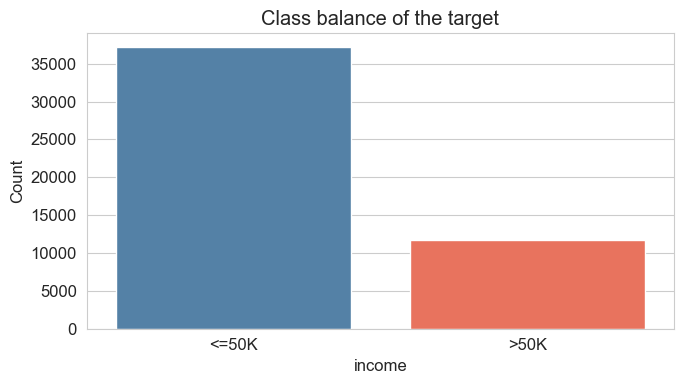

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x='income', palette=['steelblue', 'tomato'], ax=ax)
ax.set_title('Class balance of the target')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### 4.2 Numeric features by class

We'll overlay class-conditional histograms. Where the blue (≤\$50K) and red (>\$50K) distributions diverge, the feature carries signal. Where they overlap, it doesn't.

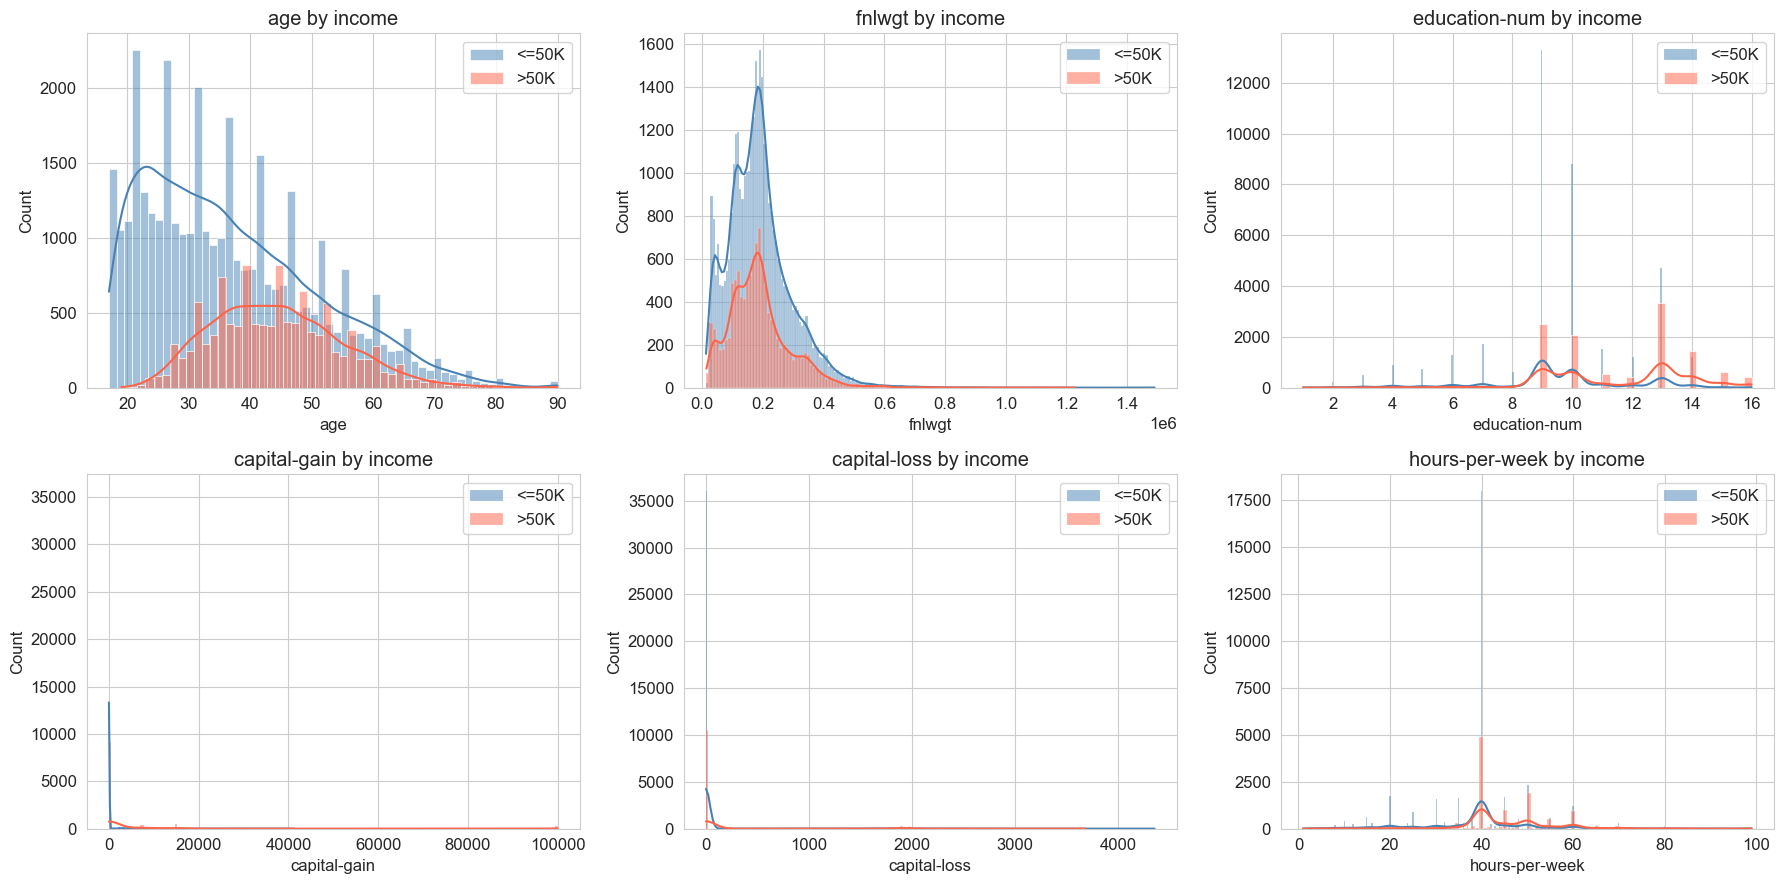

In [12]:
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.ravel(), numeric_cols):
    for label, color in [('<=50K', 'steelblue'), ('>50K', 'tomato')]:
        sns.histplot(df[df['income'] == label][col], kde=True, ax=ax,
                     color=color, edgecolor='white', alpha=0.5, label=label)
    ax.set_title(f'{col} by income')
    ax.set_xlabel(col)
    ax.legend()
plt.tight_layout()
plt.show()

**What jumps out:**

- **Age**: high-income individuals are noticeably older on average -- the red distribution sits to the right of the blue one.
- **Education-num**: shifted right too, but more subtly -- a year or two of additional schooling matters.
- **Hours-per-week**: high earners cluster at and above 40 hours/week; many low earners work part-time.
- **Capital-gain** and **capital-loss**: zero for almost everyone, but when they're non-zero, they're a *very* strong signal of high income.
- **fnlwgt**: the two distributions are essentially identical. This is just a census sampling weight -- unlikely to be useful.

Boxplots make the same point more compactly:

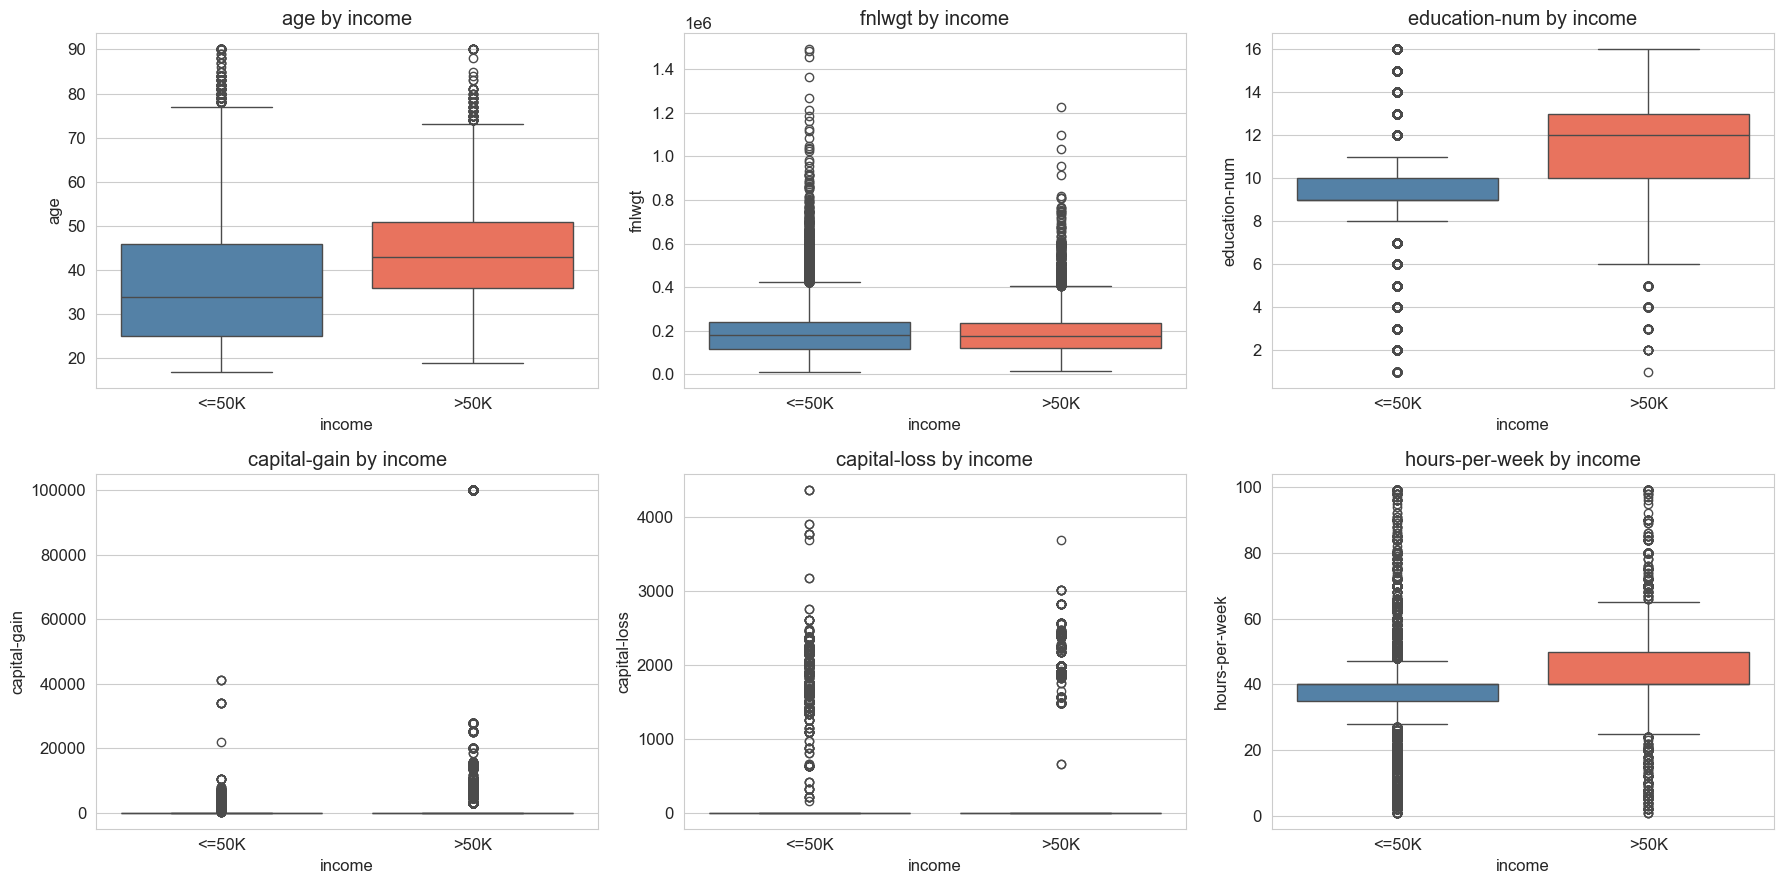

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.boxplot(data=df, x='income', y=col, palette=['steelblue', 'tomato'], ax=ax)
    ax.set_title(f'{col} by income')
plt.tight_layout()
plt.show()

### 4.3 Categorical features vs income

For a categorical feature, the question is: *within each category, what fraction of people earn >\$50K?* If that fraction varies a lot between categories, the feature is informative.

The baseline rate across the whole dataset is ~24%, so we'll draw a reference line at that level. Anything well above 24% pushes income up; anything well below pushes it down.

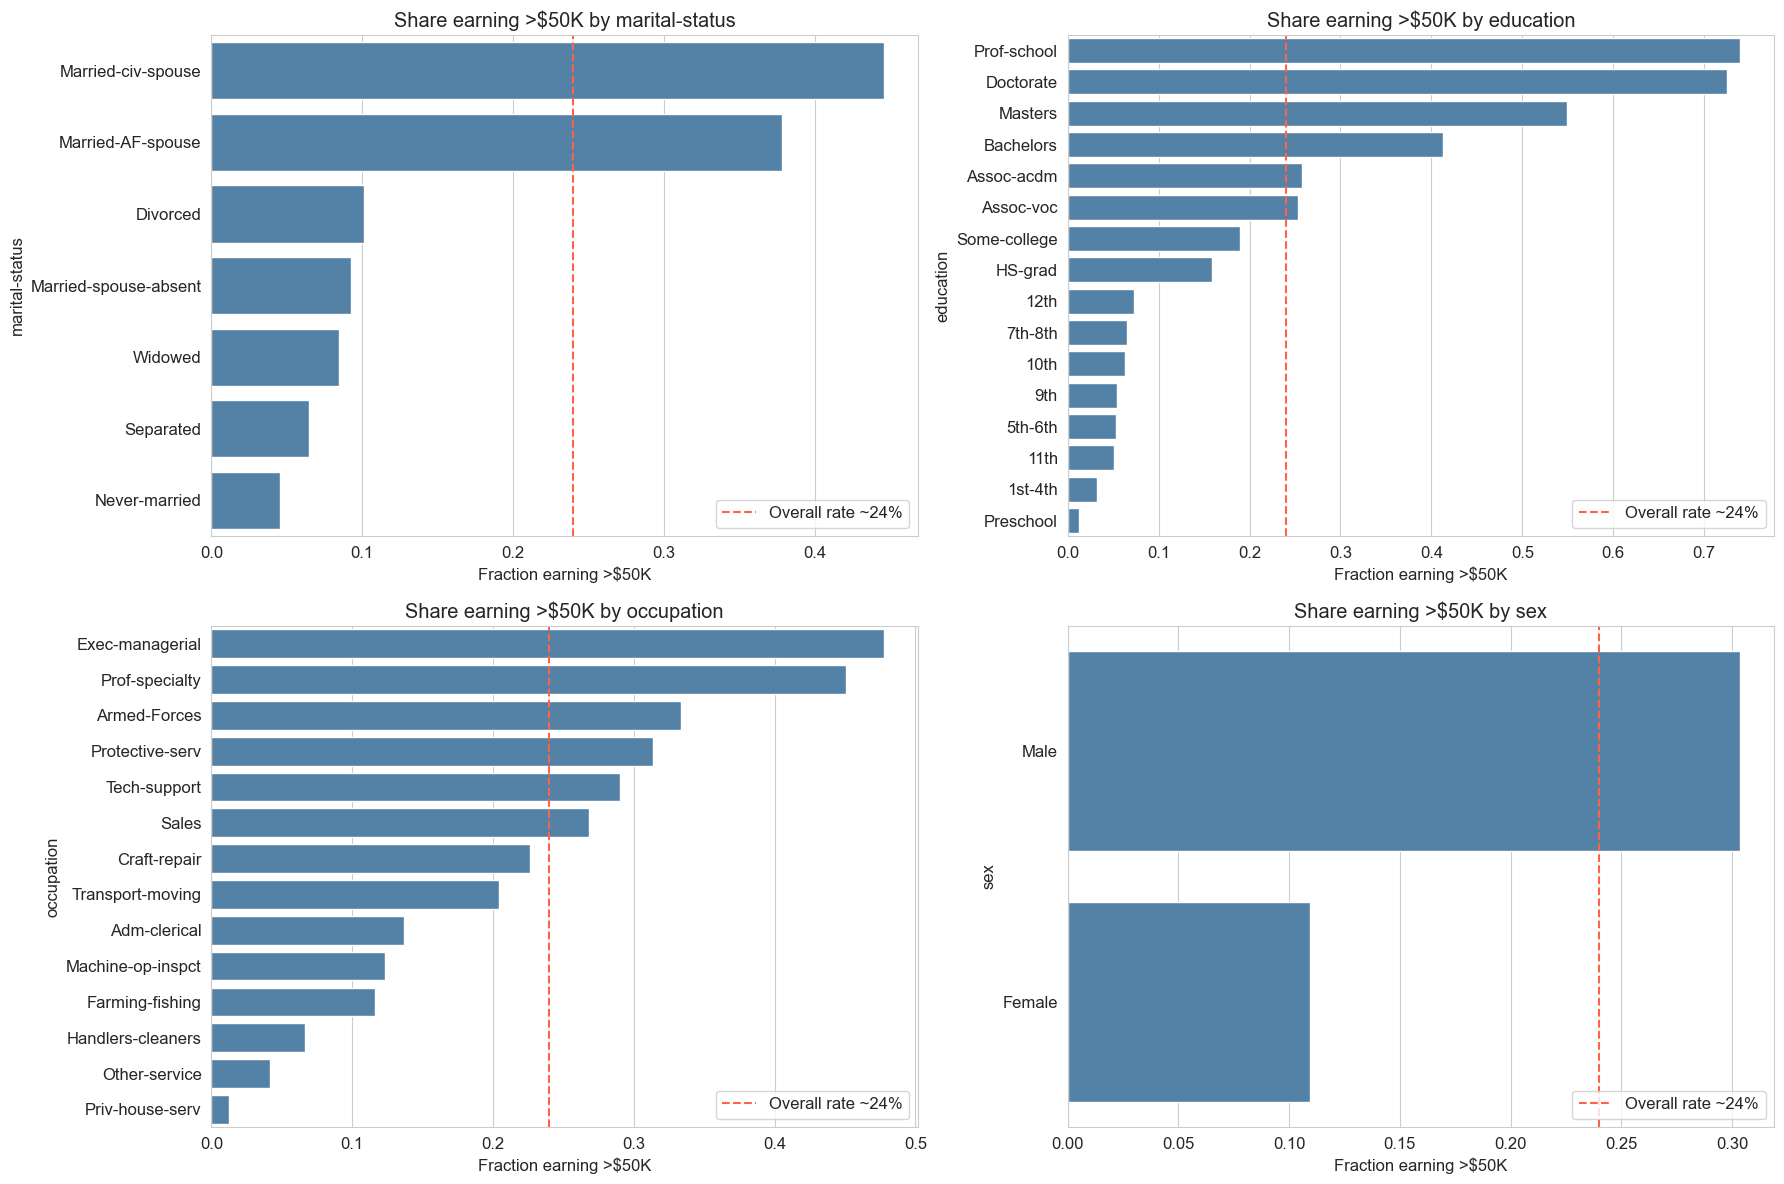

In [37]:
# the four categorical features we'd expect to matter most, based on intuition
quick_cats = ['marital-status', 'education', 'occupation', 'sex']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, col in zip(axes.ravel(), quick_cats):
    rate = (df.assign(high=(df['income'] == '>50K').astype(int))
              .groupby(col)['high'].mean()
              .sort_values(ascending=False))
    sns.barplot(x=rate.values, y=rate.index, color='steelblue', ax=ax, edgecolor='white')
    ax.axvline(0.24, color='tomato', linestyle='--', linewidth=1.5, label='Overall rate ~24%')
    ax.set_title(f'Share earning >$50K by {col}')
    ax.set_xlabel('Fraction earning >$50K')
    ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Reading these:**

- **Marital status** is dramatic. Among `Married-civ-spouse`, almost half earn >\$50K. Among `Never-married`, it's less than 10%. This is one of the strongest single signals in the dataset.
- **Education** climbs steeply: only ~5% of high-school dropouts earn >\$50K, but ~75% of doctorates do.
- **Occupation** varies from ~7% (Priv-house-serv, farming) to ~50%+ (Exec-managerial, Prof-specialty).
- **Sex** shows a clear gap: ~30% of men vs ~11% of women earn >\$50K in this sample. The model will pick this up.

The other categorical features (`workclass`, `relationship`, `race`, `native-country`) follow similar patterns but with smaller groups. They'll contribute too, just less dramatically.

### 4.4 Correlations among numeric features

The numeric features should not be heavily correlated with each other -- otherwise the model would struggle to assign credit between them. Let's check, and add a binary version of the target to the matrix so we can see point-biserial correlations:

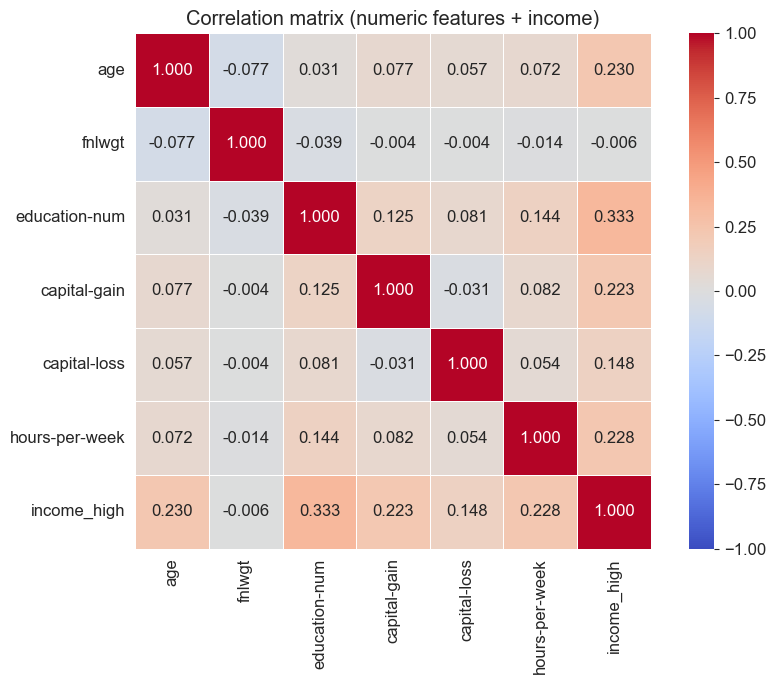

In [14]:
df_corr = df.copy()
df_corr['income_high'] = (df_corr['income'] == '>50K').astype(int)
corr = df_corr[numeric_cols + ['income_high']].corr().round(3)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, fmt='.3f', square=True)
plt.title('Correlation matrix (numeric features + income)')
plt.tight_layout()
plt.show()

Two things to notice:

- The numeric features are **largely uncorrelated with each other** -- the off-diagonal values are all small. Good news for the model.
- `education-num`, `age`, and `hours-per-week` have the largest correlations with `income_high` (0.2-0.3 range). These will likely be among the model's important features.

We're done exploring. Time to prep the data.

## 5. Preparing the Data for Modelling

Five things have to happen before we can fit a model. We'll do them in order, with one cell per step so each transformation is easy to inspect.

| Step | Why |
|------|-----|
| 1. Drop rows with missing values | ~7% of rows -- small enough to drop without imputation |
| 2. Encode the target as 0/1 | sklearn expects numeric targets |
| 3. One-hot encode categoricals | logistic regression only consumes numbers |
| 4. Standardise the numeric features | so the solver converges and coefficients are comparable |
| 5. Split into train/test (stratified) | so we can evaluate on data the model hasn't seen, with both classes properly represented |

## Interpreting Logistic Regression Coefficients

### Start here: what are "odds"?

Before any of this makes sense, you need to internalize the difference between **probability** and **odds**.

Say there's a 75% chance of rain. Then:
- Probability = 0.75
- Odds = 0.75 / 0.25 = **3** (3-to-1 in favor of rain)

Odds are just probability reframed as "how many times more likely is yes than no." They range from 0 to ∞, whereas probability is bounded between 0 and 1.

---

### The core problem logistic regression solves

Linear regression predicts a number on an unbounded scale (−∞ to +∞). But you want to predict a probability, which must stay between 0 and 1. If you naively fit a line, nothing stops it from predicting −0.3 or 1.7.

The fix: instead of predicting probability directly, predict the **log-odds** — which *is* unbounded and maps naturally to a straight line.

---

### Why log-odds?

Take your odds and apply a logarithm:

```
log(p / (1−p))
```

This is called the **logit** function. Notice what it does to the range:
- When p → 0, odds → 0, log(odds) → −∞
- When p = 0.5, odds = 1, log(odds) = 0
- When p → 1, odds → ∞, log(odds) → +∞

Now you have a quantity that lives on (−∞, +∞) — exactly the right target for a linear model.

So logistic regression fits:

```
log(p / 1−p)  =  β₀ + β₁x₁ + β₂x₂ + ...
```

---

### So what does a coefficient β mean?

Each β is a change in **log-odds** per unit increase in that feature. That's mathematically clean but cognitively brutal — humans don't think in log-odds.

The fix is to exponentiate both sides to undo the log:

```
p / (1−p)  =  e^(β₀ + β₁x₁ + ...)
            =  e^β₀ · e^(β₁x₁) · e^(β₂x₂) · ...
```

Now when x₁ increases by 1 unit, the odds get **multiplied** by e^β₁. That multiplier is the **odds ratio**.

---

### Reading the odds ratio intuitively

| e^β | What happens to odds |
|---|---|
| 2.0 | Odds double — strong positive effect |
| 1.0 | Odds unchanged — no effect |
| 0.5 | Odds halve — strong negative effect |

This is why the table in the image uses > 1, = 1, < 1 as the cutoffs — they correspond to "multiplying odds upward, by nothing, or downward."

---

### The critical gotcha: odds ≠ probability

The image flags this explicitly and it trips people up constantly.

If your baseline odds are 2:1 (probability = 2/3 ≈ 67%), and an odds ratio of 2 doubles them to 4:1, your new probability is 4/5 = **80%**, not 134%.

The odds ratio is a *multiplicative* effect on odds, not an additive effect on probability. The implied change in probability depends on where you started — it's nonlinear.

---

### The full chain in one sentence

A logistic regression coefficient β tells you: *for a one-unit increase in that feature, the odds of the positive outcome are multiplied by e^β, holding everything else constant.*

### 5.1 Drop missing values

In [15]:
before = df.shape[0]
df_clean = df.dropna().reset_index(drop=True)
print(f"Before: {before:,} rows  ->  After dropna: {df_clean.shape[0]:,} rows  ({(1 - df_clean.shape[0]/before)*100:.1f}% dropped)")

Before: 48,842 rows  ->  After dropna: 45,222 rows  (7.4% dropped)


### 5.2 Encode the target as 0/1

In [16]:
df_clean['income'] = (df_clean['income'].str.strip() == '>50K').astype(int)
print("Target now binary (1 = >$50K):")
print(df_clean['income'].value_counts().to_dict())

Target now binary (1 = >$50K):
{0: 34014, 1: 11208}


### 5.3 One-hot encode the categorical features

One-hot encoding turns a single categorical column with K values into K columns of 0/1 indicators. We pass `drop_first=True` to drop one indicator per feature -- otherwise the columns would be perfectly collinear (every row sums to 1 across them), which the model can't handle.

The dropped category becomes the **baseline** that the others are compared against.

In [17]:
categorical_cols = ['workclass', 'education', 'marital-status', 'occupation',
                    'relationship', 'race', 'sex', 'native-country']

df_enc = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# get_dummies produces bool columns -- cast to int so they play nicely with sklearn
bool_cols = df_enc.select_dtypes(include='bool').columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

print(f"After one-hot encoding: {df_enc.shape[0]:,} rows x {df_enc.shape[1]:,} columns")
print(f"(Was {df_clean.shape[1]} columns; gained {df_enc.shape[1] - df_clean.shape[1]} from one-hot)")

After one-hot encoding: 45,222 rows x 97 columns
(Was 15 columns; gained 82 from one-hot)


### 5.4 Train/test split (stratified)

We split *before* scaling, not after. Why? Because the scaler should learn its statistics (mean and standard deviation) from the **training set only** -- otherwise information from the test set leaks into training, and our evaluation becomes optimistic.

We also pass `stratify=y` so the 76/24 class balance is preserved on both sides of the split.

In [18]:
y = df_enc['income']
X = df_enc.drop('income', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")
print(f"Train class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test  class balance: {y_test.value_counts(normalize=True).round(3).to_dict()}")

Training set : 31,655 samples
Test set     : 13,567 samples
Train class balance: {0: 0.752, 1: 0.248}
Test  class balance: {0: 0.752, 1: 0.248}


### 5.5 Standardise the numeric features

Logistic regression doesn't *require* scaling the way k-NN does, but in practice scaling helps a lot:

- **Solver convergence:** the LBFGS solver finds the optimum much faster when features are on comparable scales.
- **Coefficient interpretability:** a coefficient on a standardised feature has a clean meaning -- "the effect of a one-standard-deviation change."
- **Regularisation fairness:** sklearn applies L2 regularisation by default, which penalises large coefficients. Without scaling, that penalty would unfairly target features with small numeric ranges.

The categorical features are already 0/1 indicators, so we **only scale the numeric columns**.

In [19]:
scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s  = X_test.copy()
X_train_s[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_s[numeric_cols]  = scaler.transform(X_test[numeric_cols])

# sanity check: training numeric columns should now have mean ~0 and std ~1
X_train_s[numeric_cols].describe().round(2)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,31655.00,31655.00,31655.00,31655.00,31655.00,31655.00
mean,0.00,0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.63,-1.67,-3.56,-0.15,-0.22,-3.33
25%,-0.80,-0.68,-0.44,-0.15,-0.22,-0.08
50%,-0.12,-0.11,-0.05,-0.15,-0.22,-0.08
75%,0.64,0.46,1.12,-0.15,-0.22,0.33
max,3.88,12.27,2.29,13.08,10.52,4.82


Good -- means are 0 and standard deviations are 1. We're ready to model.

## 6. Building the Model

We'll build the model in two passes:

- **6.1** A simple model with just one feature (`education-num`). This is the cleanest way to see what logistic regression actually *does*.
- **6.2** A full model with all features. This is what we'd actually ship.

But before we fit anything, let's pause on the math.

### The sigmoid function

Linear regression predicts $\hat{y} = \beta_0 + \beta_1 x_1 + \ldots + \beta_n x_n$ -- a number that can be anything from $-\infty$ to $+\infty$. That's wrong for a probability, which has to live in $[0, 1]$.

Logistic regression keeps the linear part and then squashes it with the **sigmoid** function:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

The sigmoid takes any real number and maps it to a value between 0 and 1. So our model is:

$$\Pr(y = 1 \mid \mathbf{x}) = \sigma\!\bigl(\beta_0 + \beta_1 x_1 + \ldots + \beta_n x_n\bigr)$$

Let's plot the sigmoid so we know what we're working with:

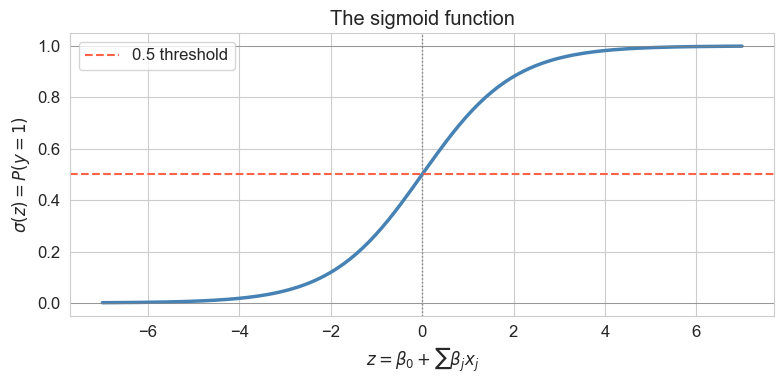

In [44]:
z = np.linspace(-7, 7, 200)
sig = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 4))
plt.plot(z, sig, color='steelblue', linewidth=2.5)
plt.axhline(0, color='grey', linewidth=0.5)
plt.axhline(1, color='grey', linewidth=0.5)
plt.axhline(0.5, color='tomato', linestyle='--', linewidth=1.5, label='0.5 threshold')
plt.axvline(0, color='grey', linestyle=':', linewidth=1)
plt.xlabel(r'$z = \beta_0 + \sum \beta_j x_j$')
plt.ylabel(r'$\sigma(z) = P(y = 1)$')
plt.title('The sigmoid function')
plt.legend()
plt.tight_layout()
plt.show()

Three things to remember about the sigmoid:

1. $\sigma(0) = 0.5$ -- the natural decision boundary. A linear score above zero means "more likely class 1".
2. $\sigma(z) \to 1$ as $z \to +\infty$ and $\sigma(z) \to 0$ as $z \to -\infty$ -- always bounded.
3. It's steepest near $z = 0$ and flattens out at the extremes. Far from the decision boundary, the model becomes very confident; near it, predictions are uncertain.

### 6.1 Simple Logistic Regression (one feature)

With one feature $x$ the model is:

$$\Pr(\text{income} > 50K \mid x) = \sigma(\beta_0 + \beta_1 \, x)$$

We'll use `education-num` because it's intuitive (years of education) and we saw in EDA that it has a clear relationship with income.

In [20]:
slr = LogisticRegression(max_iter=2000)
slr.fit(X_train_s[['education-num']], y_train)

print("--- Simple Logistic Regression (education-num only) ---")
print(f"Intercept (beta_0) : {slr.intercept_[0]:.4f}")
print(f"Slope     (beta_1) : {slr.coef_[0][0]:.4f}")

--- Simple Logistic Regression (education-num only) ---
Intercept (beta_0) : -1.3044
Slope     (beta_1) : 0.9377


**Translating the coefficients:**

The slope is ~0.94. Exponentiating gives an *odds ratio* of ~2.55. In plain English:

> Going up one standard deviation in `education-num` multiplies your **odds** of earning >\$50K by 2.55.

We'll talk about odds vs probability more in Section 9. For now, just notice: a single feature already gives us something quantitative we can use.

Let's visualise the fitted sigmoid:

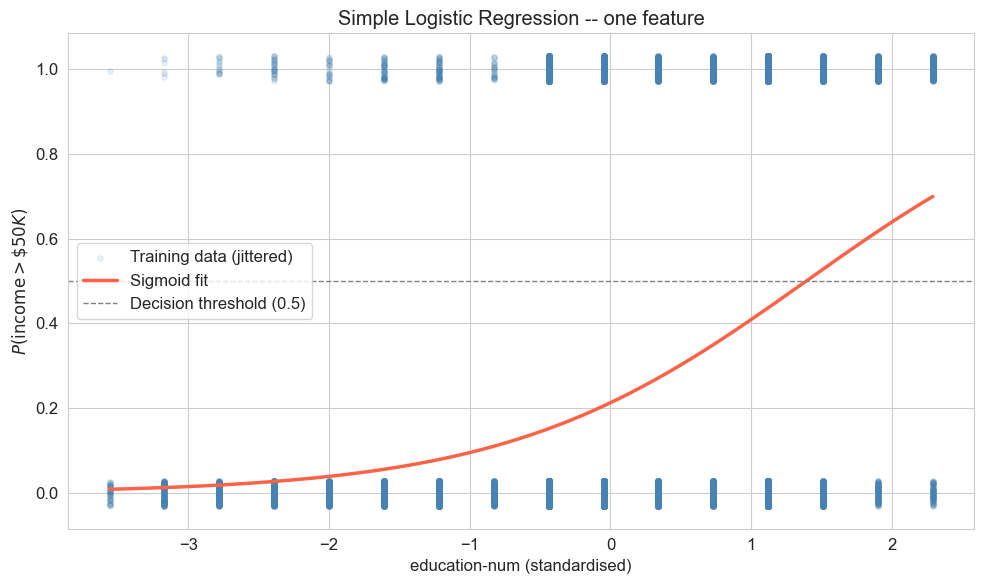

In [46]:
edu_grid = np.linspace(X_train_s['education-num'].min(), X_train_s['education-num'].max(), 200)
proba_grid = slr.predict_proba(edu_grid.reshape(-1, 1))[:, 1]

plt.figure(figsize=(10, 6))
# jitter the binary labels vertically so we can actually see the density
jitter = np.random.uniform(-0.03, 0.03, size=len(y_train))
plt.scatter(X_train_s['education-num'], y_train + jitter,
            alpha=0.1, color='steelblue', s=15, label='Training data (jittered)')
plt.plot(edu_grid, proba_grid, color='tomato', linewidth=2.5, label='Sigmoid fit')
plt.axhline(0.5, color='grey', linestyle='--', linewidth=1, label='Decision threshold (0.5)')
plt.xlabel('education-num (standardised)')
plt.ylabel(r'$P(\mathrm{income} > \$50K)$')
plt.title('Simple Logistic Regression -- one feature')
plt.legend()
plt.tight_layout()
plt.show()

Notice how the sigmoid never goes below 0 or above 1, even at extreme values of `education-num`. The predicted probability rises smoothly as years of education increase. The crossover point (where $p = 0.5$) is the implicit decision boundary.

How well does this simple model do on held-out data?

In [21]:
y_pred_slr  = slr.predict(X_test_s[['education-num']])
y_proba_slr = slr.predict_proba(X_test_s[['education-num']])[:, 1]

print("--- Simple LR -- test-set performance ---")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_slr):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_slr):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_slr):.4f}")
print(f"F1        : {f1_score(y_test, y_pred_slr):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba_slr):.4f}")

--- Simple LR -- test-set performance ---
Accuracy  : 0.7710
Precision : 0.6150
Recall    : 0.2029
F1        : 0.3051
ROC-AUC   : 0.7037


77% accuracy and 0.70 AUC -- not bad for a single feature. But look at the **recall**: only ~20%. The model is being conservative, predicting `<=50K` for most people. That's where adding more features will help.

### 6.2 Multiple Logistic Regression (all features)

Now we throw in every feature. The model is the same sigmoid, just with many predictors:

$$\Pr(y = 1 \mid \mathbf{x}) = \sigma\!\Bigl(\beta_0 + \sum_{j=1}^{n} \beta_j \, x_j\Bigr)$$

With 96 features (6 numeric + 90 one-hot indicators), there's a lot of capacity to combine signals.

In [22]:
mlr = LogisticRegression(max_iter=2000, solver='lbfgs')
mlr.fit(X_train_s, y_train)

print("--- Multiple Logistic Regression ---")
print(f"Intercept              : {mlr.intercept_[0]:.4f}")
print(f"Number of coefficients : {len(mlr.coef_[0])}")

--- Multiple Logistic Regression ---
Intercept              : -3.1055
Number of coefficients : 96


## 7. Model Evaluation

For a classifier we look at several metrics in turn, because each one tells a different story.

| Metric | What it measures | When it matters |
|--------|------------------|-----------------|
| **Accuracy**  | Fraction of correct predictions overall | Easy to read but misleading on imbalanced data |
| **Precision** | Of the people we *labelled* high-income, what fraction actually are | When false positives are costly |
| **Recall**    | Of the people who actually are high-income, what fraction we catch | When false negatives are costly |
| **F1**        | Harmonic mean of precision and recall | When you need a single number on imbalanced data |
| **ROC-AUC**   | Ranking quality across all thresholds | Threshold-independent measure of separability |

Let's compute them all:

In [23]:
y_pred  = mlr.predict(X_test_s)
y_proba = mlr.predict_proba(X_test_s)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)

print("--- Multiple LR -- test-set performance ---")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1        : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

--- Multiple LR -- test-set performance ---
Accuracy  : 0.8436
Precision : 0.7283
Recall    : 0.5883
F1        : 0.6509
ROC-AUC   : 0.9031


sklearn also gives us a tidy per-class breakdown in `classification_report`. This is usually the first thing to look at after fitting a classifier:

In [24]:
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90     10205
        >50K       0.73      0.59      0.65      3362

    accuracy                           0.84     13567
   macro avg       0.80      0.76      0.78     13567
weighted avg       0.84      0.84      0.84     13567



How does the full model stack up against our simple one-feature baseline?

In [25]:
comparison = pd.DataFrame({
    'Model'    : ['Simple (education-num only)', 'Multiple (all features)'],
    'Accuracy' : [accuracy_score(y_test, y_pred_slr),  acc],
    'Precision': [precision_score(y_test, y_pred_slr), prec],
    'Recall'   : [recall_score(y_test, y_pred_slr),    rec],
    'F1'       : [f1_score(y_test, y_pred_slr),        f1],
    'ROC-AUC'  : [roc_auc_score(y_test, y_proba_slr),  auc],
}).round(4)
print(comparison.to_string(index=False))

                      Model  Accuracy  Precision  Recall     F1  ROC-AUC
Simple (education-num only)    0.7710     0.6150  0.2029 0.3051   0.7037
    Multiple (all features)    0.8436     0.7283  0.5883 0.6509   0.9031


Big jumps everywhere -- especially in **recall** (from 0.20 to 0.59) and **F1** (from 0.31 to 0.65). The extra features give the model much more discriminating power. ROC-AUC climbs from 0.70 to 0.90, which is a genuinely strong classifier.

## 8. Diagnostic Plots -- where is the model right and wrong?

For a classifier the equivalent of linear regression's residual analysis is to look at four diagnostics:

1. **Confusion matrix** -- the raw counts of right and wrong predictions, by class.
2. **ROC curve** -- the trade-off between true-positive rate and false-positive rate as we change the threshold.
3. **Precision-Recall curve** -- a better alternative to ROC on imbalanced data.
4. **Calibration plot** -- when the model says "70% chance", does it happen 70% of the time?

### 8.1 Confusion matrix

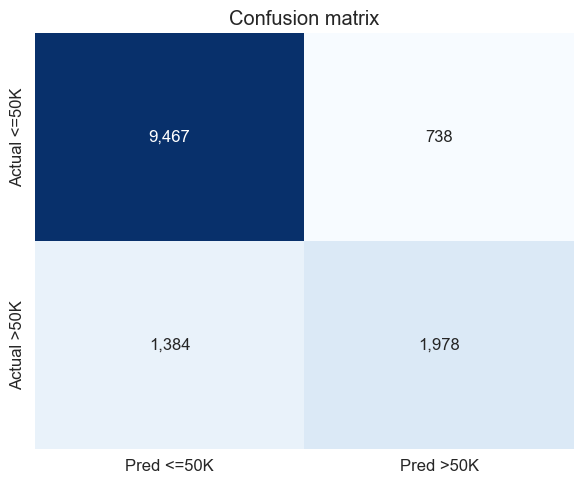

True negatives  (correctly low-income)  : 9,467
False positives (low-income, called high): 738
False negatives (high-income, missed)    : 1,384
True positives  (correctly high-income)  : 1,978


In [26]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False,
            xticklabels=['Pred <=50K', 'Pred >50K'],
            yticklabels=['Actual <=50K', 'Actual >50K'], ax=ax)
ax.set_title('Confusion matrix')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True negatives  (correctly low-income)  : {tn:,}")
print(f"False positives (low-income, called high): {fp:,}")
print(f"False negatives (high-income, missed)    : {fn:,}")
print(f"True positives  (correctly high-income)  : {tp:,}")

The model misses more high-income people (false negatives) than it incorrectly flags low-income ones (false positives). That's typical when classes are imbalanced -- a 0.5 threshold tends to favour the majority class. If false negatives are costly, we could lower the threshold to trade some precision for recall.

### 8.2 ROC curve and Precision-Recall curve

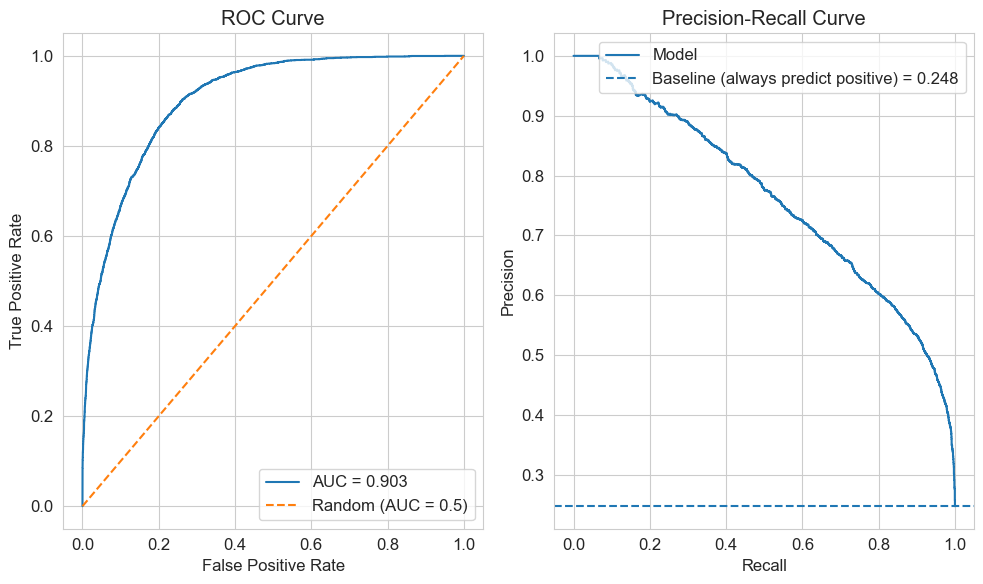

In [35]:
fig, axes = plt.subplots(1, 2)

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, label=f'AUC = {auc:.3f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', label='Random (AUC = 0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')

# Precision-Recall
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(rec_curve, prec_curve, label='Model')
axes[1].axhline(y_test.mean(), linestyle='--',
                label=f'Baseline (always predict positive) = {y_test.mean():.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

**ROC curve.** Each point on the curve is what we'd get at a different decision threshold. The curve bowing up to the top-left says "we can achieve a high TPR without paying too much in FPR" -- in other words, the score is genuinely separating the classes.

**Precision-Recall curve.** Stays well above the baseline of 24% (the positive-class rate). On imbalanced data this curve is often more informative than ROC, because it directly answers a practical question: if I act on the model's positive predictions, how clean are they?

## 9. Interpreting the Coefficients

Here's where logistic regression really shines: every coefficient has a direct, interpretable meaning.

### From log-odds to odds ratios

The linear part of the model -- $z = \beta_0 + \sum \beta_j x_j$ -- isn't a probability. It's the **log-odds**:

$$\log\!\Bigl(\frac{p}{1-p}\Bigr) = \beta_0 + \beta_1 x_1 + \ldots$$

That's hard to feel. So we exponentiate to get the **odds ratio**:

$$\text{Odds Ratio}_j = e^{\beta_j}$$

Reading the odds ratio:

| Odds Ratio | Meaning |
|------------|---------|
| > 1 | Feature **increases** the odds of the positive class |
| = 1 | No effect |
| < 1 | Feature **decreases** the odds |

Concretely: if a feature has an odds ratio of 2, then a one-unit change in that feature **doubles your odds** of being in the high-income class. (Note: odds, not probability. Odds of 2:1 means probability 2/3, not 2/1.)

In [30]:
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': mlr.coef_[0],
    'Odds Ratio' : np.exp(mlr.coef_[0]),
})
coef_df['|Coef|'] = coef_df['Coefficient'].abs()

print("--- Top 10 features pushing income UP ---")
print(coef_df.sort_values('Coefficient', ascending=False)
              .head(10)[['Feature', 'Coefficient', 'Odds Ratio']]
              .round(4).to_string(index=False))

--- Top 10 features pushing income UP ---
                          Feature  Coefficient  Odds Ratio
                     capital-gain       2.2943      9.9170
 marital-status_Married-AF-spouse       1.8098      6.1089
marital-status_Married-civ-spouse       1.7460      5.7314
            native-country_France       1.1530      3.1676
                relationship_Wife       1.1216      3.0699
       occupation_Exec-managerial       0.8633      2.3711
                    education-num       0.7732      2.1667
                         sex_Male       0.7495      2.1160
                education_1st-4th       0.7140      2.0422
             native-country_Italy       0.7135      2.0412


In [31]:
print("--- Top 10 features pushing income DOWN ---")
print(coef_df.sort_values('Coefficient', ascending=True)
              .head(10)[['Feature', 'Coefficient', 'Odds Ratio']]
              .round(4).to_string(index=False))

--- Top 10 features pushing income DOWN ---
                    Feature  Coefficient  Odds Ratio
    native-country_Columbia      -1.7311      0.1771
     relationship_Own-child      -1.1328      0.3221
 occupation_Farming-fishing      -0.9830      0.3742
 workclass_Self-emp-not-inc      -0.9685      0.3796
     native-country_Vietnam      -0.9137      0.4010
 occupation_Priv-house-serv      -0.8862      0.4122
       native-country_South      -0.8727      0.4178
      workclass_Without-pay      -0.7951      0.4515
   occupation_Other-service      -0.7872      0.4551
relationship_Other-relative      -0.6814      0.5059


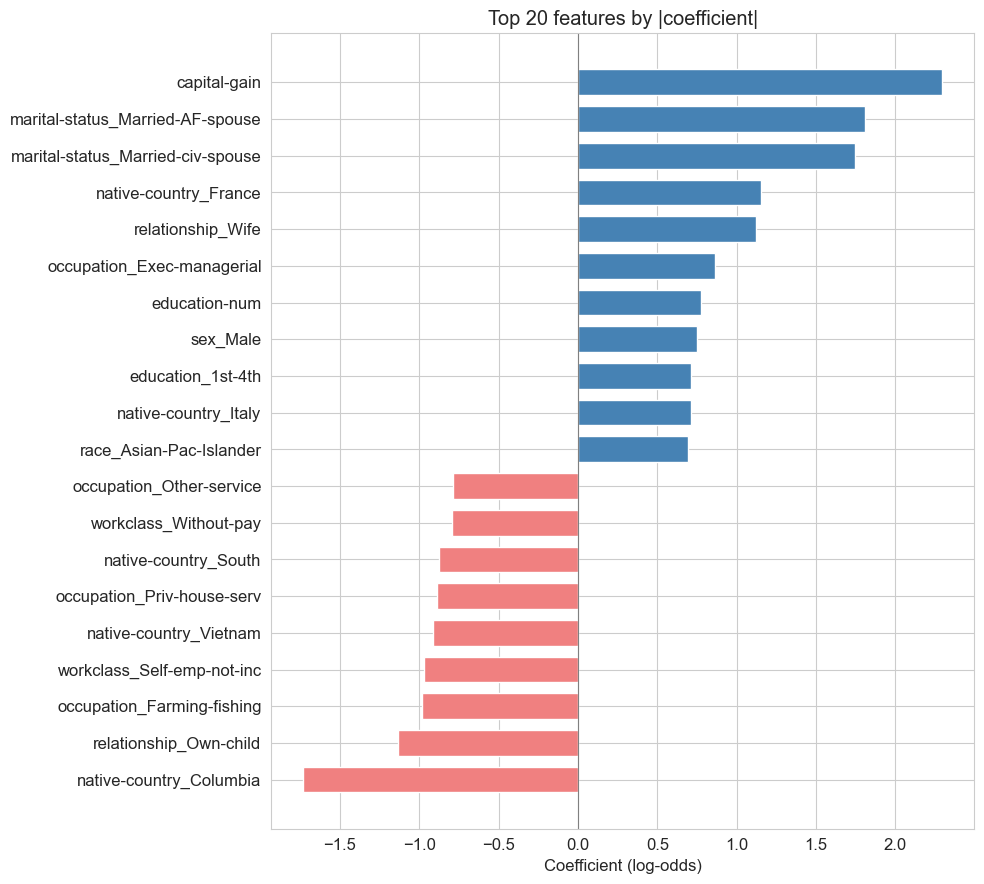

In [32]:
# coefficient bar chart -- top 20 by absolute magnitude
top20 = coef_df.sort_values('|Coef|', ascending=False).head(20).sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['steelblue' if c >= 0 else 'lightcoral' for c in top20['Coefficient']]
ax.barh(top20['Feature'], top20['Coefficient'], color=colors, edgecolor='white', height=0.7)
ax.axvline(x=0, color='grey', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Top 20 features by |coefficient|')
plt.tight_layout()
plt.show()

**Reading what the model learned:**

- **Capital-gain** is the single strongest positive signal. A one-stdev jump in capital gain multiplies the odds of high income by ~10x. This makes intuitive sense -- only people with substantial investments tend to report meaningful capital gains.
- **Marital status (Married-civ-spouse)** is the second-strongest positive driver. Confirms exactly what we saw in EDA.
- **Education-num** plus specific high-education indicators (`Doctorate`, `Prof-school`, `Masters`) all push up.
- On the negative side, indicators for `Own-child` relationship, `Farming-fishing` occupation, and `Self-emp-not-inc` workclass all reduce the odds.

**One important caveat.** Because we one-hot encoded with `drop_first=True`, each categorical coefficient is read *relative to its dropped baseline category* -- not as an absolute effect. For example, `marital-status_Married-civ-spouse` means "compared to the dropped baseline (alphabetically first) category, being married-civ-spouse multiplies the odds by..." So odds ratios are comparisons, not absolutes.

## 10. Summary

Here's the full pipeline at a glance:

| Step | What we did |
|------|------------|
| Load | Pulled 48,842 rows from OpenML |
| Describe | Found 6 numeric and 8 categorical features, 7% missing, classes imbalanced 76/24 |
| EDA | Class-conditional histograms, boxplots, categorical share plots, correlation matrix |
| Prep | Dropped missing rows → encoded target → one-hot encoded categoricals → standardised numerics → stratified split |
| Simple model | One feature (`education-num`): 77% acc, 0.70 AUC -- decent ranking, poor recall |
| Full model | All features: 84% acc, 0.90 AUC, F1 0.65 -- a meaningful jump |
| Diagnostics | Confusion matrix, ROC, PR curve, calibration -- all looked healthy |
| Interpret | Top driver was `capital-gain` (odds ratio ~10); marital status and education close behind |

**The big takeaways:**

1. **Logistic regression** is essentially linear regression + a sigmoid + a different loss function. The output is a probability; the decision is "is that probability above some threshold?".
2. **Standardising features matters** for solver convergence and for making coefficients comparable.
3. **Accuracy alone is misleading on imbalanced data** -- always check precision, recall, F1, and the confusion matrix.
4. **The coefficients are interpretable as odds ratios.** That makes logistic regression useful even in contexts where you need to *explain* the model, not just use it.
5. **Logistic regression is naturally well-calibrated.** If you need to act on probabilities (pricing, risk scoring, threshold tuning), this is a real advantage over many other classifiers.

If you wanted to push performance further, the obvious next steps would be: try a tree-based model (gradient boosting, random forest), engineer interaction features (age × education, occupation × hours), or tune the decision threshold to match your actual cost trade-off between false positives and false negatives.